# 05 - Baseline Model Comparison

Trains and compares baseline classifiers on the processed earthquake-stock dataset.

**Target:** `target_signal` -> `0 = SELL`, `1 = HOLD`, `2 = BUY`

**Outputs**
- `models/scaler.pkl`
- `results/metrics/model_comparison.csv`

The LSTM is added to the comparison in notebook `06_lstm_model.ipynb`.

## 0. Setup (works locally and on Google Colab)

In [1]:
# Works both locally and on Google Colab.
# Locally: do nothing, notebooks run from the repo's notebooks/ folder.
# Colab:   clone the repo once and cd into it so the ../ paths resolve.
import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/yumelab-studio/avaia-seismofinance.git"
    repo_folder = "avaia-seismofinance"
    if not os.path.exists(repo_folder):
        os.system(f"git clone {REPO_URL}")
    os.chdir(os.path.join(repo_folder, "notebooks"))

print("Working directory:", os.getcwd())


Working directory: C:\Users\vanes\OneDrive\Desktop\avaia-seismofinance-main\notebooks


## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)


## 2. Load dataset & sanity checks

In [3]:
data_path = "../data/processed/model_dataset.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (3389, 35)
Columns: ['date', 'ticker', 'close', 'return', 'market_return', 'abnormal_return', 'quake_count_1d', 'max_magnitude_1d', 'avg_magnitude_1d', 'avg_depth_1d', 'min_depth_1d', 'energy_sum_1d', 'energy_max_1d', 'quake_count_3d', 'max_magnitude_3d', 'energy_sum_3d', 'min_distance_tokyo_km', 'min_distance_osaka_km', 'min_distance_sendai_km', 'min_distance_fukushima_km', 'min_distance_major_city_km', 'days_since_last_quake', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'rolling_return_5', 'rolling_return_10', 'volatility_5', 'volatility_10', 'volatility_20', 'volume_change', 'target_return_next_day', 'target_abnormal_return_next_day', 'target_signal']


,date,ticker,close,return,market_return,abnormal_return,quake_count_1d,max_magnitude_1d,avg_magnitude_1d,avg_depth_1d,...,return_lag_5,rolling_return_5,rolling_return_10,volatility_5,volatility_10,volatility_20,volume_change,target_return_next_day,target_abnormal_return_next_day,target_signal
0,2011-01-03,8766.T,1000.012302,NaN,NaN,NaN,0.0,0.00000,0.00000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002987,0.006703,2
1,2011-01-04,8766.T,1002.999794,0.002987,-0.003715,0.006703,0.0,0.00000,0.00000,0.000000,...,NaN,0.002987,0.002987,NaN,NaN,NaN,0.028186,-0.002741,-0.003145,1
2,2011-01-05,8766.T,1000.250192,-0.002741,0.000404,-0.003145,0.0,0.00000,0.00000,0.000000,...,NaN,0.000123,0.000123,0.004051,0.004051,0.004051,-0.152414,-0.008906,-0.014396,0
3,2011-01-06,8766.T,991.342045,-0.008906,0.005490,-0.014396,1.0,7.21082,7.21082,71.699043,...,NaN,-0.002887,-0.002887,0.005948,0.005948,0.005948,0.026938,-0.004547,0.009508,2
4,2011-01-07,8766.T,986.834702,-0.004547,-0.014054,0.009508,0.0,0.00000,0.00000,0.000000,...,NaN,-0.003302,-0.003302,0.004927,0.004927,0.004927,-0.722476,-0.009916,-0.023392,0


In [4]:
print("Missing values per column (only columns with NaN):")
na = df.isna().sum()
print(na[na > 0])

print("\nTarget signal distribution:")
print(df["target_signal"].value_counts(dropna=False).sort_index())
print("\nProportions (%):")
print((df["target_signal"].value_counts(normalize=True).sort_index() * 100).round(1))


Missing values per column (only columns with NaN):
return                   1
market_return            1
abnormal_return          1
days_since_last_quake    4
return_lag_1             2
return_lag_2             3
return_lag_3             4
return_lag_5             6
rolling_return_5         1
rolling_return_10        1
volatility_5             2
volatility_10            2
volatility_20            2
volume_change            1
dtype: int64

Target signal distribution:
target_signal
0    1206
1    1046
2    1137
Name: count, dtype: int64

Proportions (%):
target_signal
0    35.6
1    30.9
2    33.5
Name: proportion, dtype: float64


## 3. Encode target (if it ever arrives as text)

In [5]:
# Labels are expected to be 0=SELL, 1=HOLD, 2=BUY.
# If they ever arrive as text, encode them consistently.
if df["target_signal"].dtype == object:
    mapping = {"SELL": 0, "HOLD": 1, "BUY": 2}
    df["target_signal"] = df["target_signal"].map(mapping)
    print("Target encoded from text: SELL=0, HOLD=1, BUY=2")
else:
    print("Target already numeric:", sorted(df["target_signal"].dropna().unique().tolist()))

LABELS = ["SELL", "HOLD", "BUY"]


Target already numeric: [0, 1, 2]


## 4. Sort by date (no random shuffling)

In [6]:
# Sort chronologically. The dataset contains a single ticker (8766.T),
# so the series is one continuous timeline. We still sort by [ticker, date]
# so the same code stays correct if more tickers are added later.
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
print("Tickers:", df["ticker"].unique().tolist())
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())


Tickers: ['8766.T']
Date range: 2011-01-03 -> 2023-12-28


## 5. Define feature columns (no data leakage)

In [7]:
# Feature columns used as model INPUTS.
# Excluded on purpose (data-leakage / not numeric):
#   target_return_next_day, target_abnormal_return_next_day, target_signal  (future / target)
#   date     -> used only for sorting, never as a raw numeric feature
#   ticker   -> single ticker here, so it carries no information; left out
feature_cols = [
    "close", "return", "market_return", "abnormal_return",
    "quake_count_1d", "max_magnitude_1d", "avg_magnitude_1d",
    "avg_depth_1d", "min_depth_1d", "energy_sum_1d", "energy_max_1d",
    "quake_count_3d", "max_magnitude_3d", "energy_sum_3d",
    "min_distance_tokyo_km", "min_distance_osaka_km", "min_distance_sendai_km",
    "min_distance_fukushima_km", "min_distance_major_city_km", "days_since_last_quake",
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5",
    "rolling_return_5", "rolling_return_10",
    "volatility_5", "volatility_10", "volatility_20",
    "volume_change",
]
print(f"{len(feature_cols)} feature columns selected.")


30 feature columns selected.


## 6. Handle missing values

In [8]:
# Only a handful of rows have NaN (mostly the first rows where lagged/rolling
# features cannot be computed). We drop them: this is cleaner than imputation
# and avoids any leakage from filling values using statistics of the test set.
print("NaN in feature columns before cleaning:")
print(df[feature_cols].isna().sum()[lambda s: s > 0])

before = len(df)
df = df.dropna(subset=feature_cols + ["target_signal"]).reset_index(drop=True)
df["target_signal"] = df["target_signal"].astype(int)
print(f"\nRows: {before} -> {len(df)} after dropping NaN")


NaN in feature columns before cleaning:
return                   1
market_return            1
abnormal_return          1
days_since_last_quake    4
return_lag_1             2
return_lag_2             3
return_lag_3             4
return_lag_5             6
rolling_return_5         1
rolling_return_10        1
volatility_5             2
volatility_10            2
volatility_20            2
volume_change            1
dtype: int64

Rows: 3389 -> 3382 after dropping NaN


## 7. Time-based train / test split (80 / 20)

In [9]:
# Time-based split (NO random shuffling): train on the past, test on the future.
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df  = df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df["target_signal"]
X_test  = test_df[feature_cols]
y_test  = test_df["target_signal"]

print(f"Train: {len(train_df)} rows  ({train_df['date'].min().date()} -> {train_df['date'].max().date()})")
print(f"Test : {len(test_df)} rows  ({test_df['date'].min().date()} -> {test_df['date'].max().date()})")


Train: 2705 rows  (2011-01-11 -> 2021-05-24)
Test : 677 rows  (2021-05-25 -> 2023-12-27)


## 8. Scale features (fit on train only)

In [10]:
# Fit the scaler on TRAIN ONLY, then apply to both (no leakage from the test set).
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")
print("Saved scaler -> models/scaler.pkl")


Saved scaler -> models/scaler.pkl


## 9. Train & compare baseline models

We report **macro F1** as the headline metric because it weights all three classes equally - accuracy alone can look fine while ignoring a whole class.

In [11]:
def metrics_row(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

models = {
    # A "predict the most frequent class" reference point. Any useful model must beat its macro-F1.
    "Majority Baseline":   DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                                  class_weight="balanced", n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)":           SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(n_neighbors=15),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append(metrics_row(name, y_test, y_pred))
    fitted[name] = model

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df.round(4)


,model,accuracy,precision_macro,recall_macro,f1_macro
0,Gradient Boosting,0.3560,0.3572,0.3516,0.3408
1,Random Forest,0.3383,0.3316,0.3347,0.3314
2,KNN,0.3279,0.3244,0.3258,0.3200
3,SVM (RBF),0.3117,0.3094,0.3099,0.3095
4,Logistic Regression,0.3028,0.2959,0.3007,0.2942
5,Majority Baseline,0.3353,0.1118,0.3333,0.1674


## 10. Save comparison metrics

In [12]:
os.makedirs("../results/metrics", exist_ok=True)
results_df.to_csv("../results/metrics/model_comparison.csv", index=False)
print("Saved -> results/metrics/model_comparison.csv")

best_name = results_df.iloc[0]["model"]
print(f"\nBest baseline by macro F1: {best_name} (F1={results_df.iloc[0]['f1_macro']:.4f})")


Saved -> results/metrics/model_comparison.csv

Best baseline by macro F1: Gradient Boosting (F1=0.3408)


## 11. Best baseline - detailed report

Classification report - Gradient Boosting:

              precision    recall  f1-score   support

        SELL       0.35      0.47      0.40       227
        HOLD       0.36      0.18      0.24       213
         BUY       0.37      0.41      0.39       237

    accuracy                           0.36       677
   macro avg       0.36      0.35      0.34       677
weighted avg       0.36      0.36      0.34       677



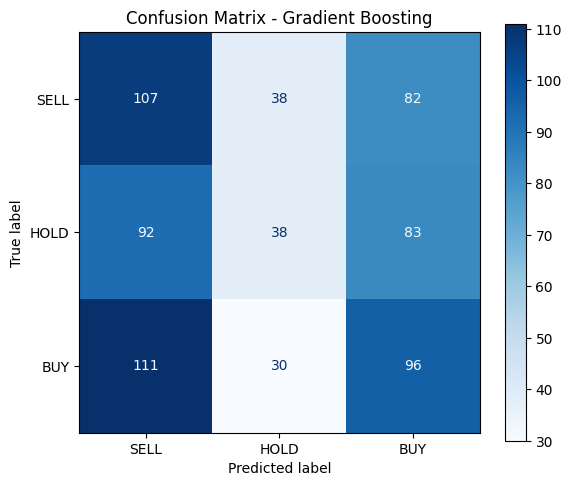

In [13]:
# Detailed look at the best baseline.
best_model = fitted[best_name]
y_pred_best = best_model.predict(X_test_scaled)
print(f"Classification report - {best_name}:\n")
print(classification_report(y_test, y_pred_best, target_names=LABELS, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()


## Notes

- The **Majority Baseline** predicts only the most common class. Its low macro F1 (~0.17) is the floor every real model must clear.
- All inputs are scaled with a scaler fit on the training period only, so no future information leaks into training.
- Next: `06_lstm_model.ipynb` trains the LSTM and appends it to this comparison.